In [ ]:
file1 = 'sm_multi.csv'
file2 = 'ps_multi.csv'

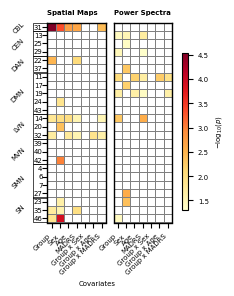

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import matplotlib as mpl

# Convert mm to inches
width_npp = 7.08661

# Create the figure with the new size
fig, ax = plt.subplots(
    figsize=(width_npp, 2.5),
    ncols=2,
    gridspec_kw={'width_ratios': [0.8, 1], 'wspace': -0.77}
)

mpl.rcParams['font.family'] = 'sans-serif'  # or 'sans-serif', 'monospace'
#mpl.rcParams['font.serif'] = ['Times New Roman']  # Change to desired font
mpl.rcParams['font.size'] = 5  # Adjust default font size



# Load and preprocess the first dataframe
df1 = pd.read_csv(file1, index_col=['Network', 'Component'])
#df1=df1.iloc[:,:-1]
df1 = df1.T
df1 = -np.log10(df1)

# Load and preprocess the second dataframe
df2 = pd.read_csv(file2, index_col=['Network', 'Component'])
#df2=df2.iloc[:,:-1]
df1 = df1.T
df2 = -np.log10(df2)

# Sort and index the dataframes by network and component
df1 = df1.sort_index(level=['Network', 'Component'])
df2 = df2.sort_index(level=['Network', 'Component'])

# Combine all dataframes to find the overall minimum and maximum values (so colorbar can be used for both plots)
combined_df = pd.concat([df1.stack(), df2.stack()])
overall_min = combined_df.min()
overall_max = combined_df.max()

# Create hierarchical y-axis labels so outer label is network and inner label is component number
networks = df1.index.get_level_values('Network')
components = df1.index.get_level_values('Component')
y_labels_inner = [f"{comp}" for comp in components]

# Plot the first heatmap
sns.heatmap(df1, annot=False, cmap="YlOrRd",
            mask=df1.isna(), linewidths=.5, linecolor='grey', ax=ax[0], square=True, cbar=False, vmin=overall_min, vmax=overall_max)
#ax[0].set_yticks([])
ax[0].set_yticks(np.arange(df1.shape[0]) + 0.5)
ax[0].set_yticklabels(y_labels_inner, ha="right", fontsize=5)
ax[0].tick_params(axis='y', pad=0)  # increase pad value to move labels farther from axis
ax[0].set_xticks(np.arange(df1.shape[1]) + 0.5)
ax[0].set_xticklabels(df1.columns, ha="right", rotation=45, fontsize=5)
ax[0].set_title("Spatial Maps", fontsize=5, loc='left', weight='bold')
ax[0].set_xlabel("")  # Remove x-axis label
ax[0].set_ylabel("")  # Remove y-axis label

# Add borders and network labels around tick labels on the left plot
prev_network = None
network_start = 0
for i, (network, component) in enumerate(df1.index):
    if network != prev_network and prev_network is not None:
        # Skip drawing rectangles for the outer labels
        if i > 0:
            # Draw a rectangle around the group of components
            rect = patches.Rectangle((-1.7, network_start - 0), 1.7, i - network_start + 0.0, linewidth=0.5, 
                                     edgecolor='black', facecolor='none', transform=ax[0].transData, clip_on=False)
            ax[0].add_patch(rect)
        # Add network label
        mid_pos = (network_start + i - 1) / 2
        ax[0].text(-2.6, mid_pos, prev_network, ha='right', va='center_baseline', 
                   fontsize=5, rotation=45)#, bbox=dict(facecolor='white', edgecolor='none'))
        network_start = i
    prev_network = network
# Draw a rectangle around the last group
rect = patches.Rectangle((-1.7, network_start - 0.), 1.7, len(df1.index) - network_start + 0.0, linewidth=0.5, 
                         edgecolor='black', facecolor='none', transform=ax[0].transData, clip_on=False)
ax[0].add_patch(rect)
# Add the last network label
mid_pos = (network_start + len(df1.index) - 1) / 2
ax[0].text(-2.6, mid_pos, prev_network, ha='right', va='center_baseline', fontsize=5, 
           rotation=45)

# Add border lines to the first plot
for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# Plot the second heatmap
sns.heatmap(df2, annot=False, cmap="YlOrRd",
            mask=df2.isna(), linewidths=0.5, linecolor='grey', ax=ax[1], square=True, cbar=False, vmin=overall_min, vmax=overall_max)
ax[1].set_yticks([])  # Remove y-ticks
ax[1].set_yticklabels([])  # Remove y-tick labels
ax[1].set_xticks(np.arange(df2.shape[1]) + 0.5)
ax[1].set_xticklabels(df2.columns, ha="right", rotation=45, fontsize=5)
ax[1].set_title("Power Spectra", fontsize=5, loc='left', weight='bold')
ax[1].set_xlabel("")  # Remove x-axis label
ax[1].set_ylabel("")  # Remove y-axis label

# Add border lines to the second plot
for spine in ax[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# Adjust layout of the plots
plt.subplots_adjust(left=0.4, right=0.9, top=0.9, bottom=0.1)

# Add a shared x-axis label for the first two plots and add title for both
fig.text(0.61, -0.15, "Covariates", ha='center', fontsize=5)
#fig.text(0.61, 0.95, "Multivariate Level Group and Mood Effects on \nResting State Brain Network Connectivity", 
   #      ha='center', fontsize=14)

# Add a color bar
cbar_ax = fig.add_axes([0.73, 0.15, 0.008, 0.63])  # Position color bar
cbar = plt.colorbar(ax[0].collections[0], cax=cbar_ax)
cbar.set_label(r'$-\log_{10}(\mathit{p})$', fontsize=5)
cbar.ax.tick_params(labelsize=5)  # or whatever size you want


# Save the combined plot
plt.savefig(
    'multi_sweet_sans_serif.png',
    dpi=400,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
